In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Embedding,Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
cols=[
'target',
'id',
'date',
'flag',
'user',
'text'
]

df=pd.read_csv(
'C:/Users/Admin/Downloads/archive (1)/training.1600000.processed.noemoticon.csv',
encoding='latin-1',
names=cols
)

print(df.head())

   target          id                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [3]:
df['trend_label']=df['target'].replace(
{4:1,0:0}
)

# reduce size for fast run
df=df.sample(10000,random_state=42)


In [4]:
def clean_text(text):
    
    text=text.lower()
    text=re.sub(r"http\S+","",text)
    text=re.sub(r"@\w+","",text)
    text=re.sub(r"[^a-zA-Z ]","",text)
    
    return text

df["text"]=df["text"].apply(clean_text)


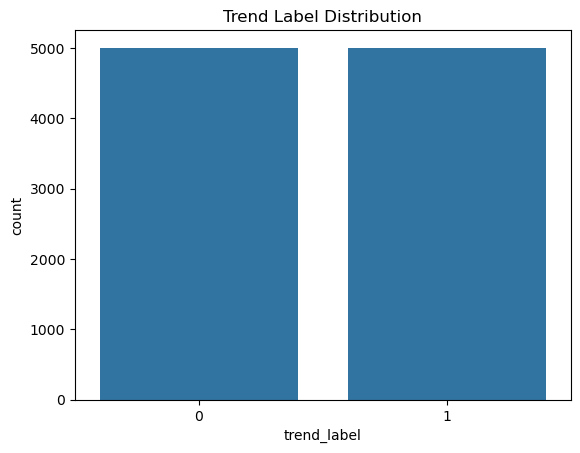

In [5]:
sns.countplot(
x='trend_label',
data=df
)
plt.title("Trend Label Distribution")
plt.show()



In [6]:

X_text=df["text"]
y=df["trend_label"]

tokenizer=Tokenizer(
num_words=5000
)

tokenizer.fit_on_texts(X_text)

seq=tokenizer.texts_to_sequences(
X_text
)

X=pad_sequences(
seq,
maxlen=50
)
X_train,X_test,y_train,y_test=\
train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [10]:
model=Sequential()
model.add(Embedding(5000,128,input_length=50))
model.add(LSTM(128))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.build(input_shape=(None,50))
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 50, 128)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 779,905 (2.98 MB)

 Trainable params: 779,905 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history=model.fit(
X_train,
y_train,
epochs=5,
batch_size=64,
validation_split=0.2
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 159ms/step - accuracy: 0.6322 - loss: 0.6373 - val_accuracy: 0.7344 - val_loss: 0.5440
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step - accuracy: 0.7903 - loss: 0.4562 - val_accuracy: 0.7406 - val_loss: 0.5239
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.8519 - loss: 0.3461 - val_accuracy: 0.7287 - val_loss: 0.5924
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.8928 - loss: 0.2645 - val_accuracy: 0.7287 - val_loss: 0.6642
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.9234 - loss: 0.1960 - val_accuracy: 0.7131 - val_loss: 0.8539


In [12]:
pred=(model.predict(X_test)>0.5).astype(int)
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step
              precision    recall  f1-score   support

           0       0.71      0.70      0.70       980
           1       0.71      0.72      0.72      1020

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000

[[682 298]
 [283 737]]


In [ ]:
def predict_trend(post):

    post=clean_text(post)

    seq=tokenizer.texts_to_sequences([post])

    pad=pad_sequences(
        seq,
        maxlen=50
    )

    result=model.predict(pad)

    if result > 0.5:
        print("\nEmerging Trend Detected")
    else:
        print("\nNot Trending")


# Real-time Dynamic Input Loop
while True:

    user_post=input(
    "\nEnter live social media post (type exit to stop): "
    )

    if user_post.lower()=="exit":
        print("Real-time monitoring stopped")
        break

    predict_trend(user_post)


Enter live social media post (type exit to stop):  Vijay movie is verithanam


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

Emerging Trend Detected



Enter live social media post (type exit to stop):  Ipl match csk win


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

Not Trending



Enter live social media post (type exit to stop):  education is important


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

Emerging Trend Detected



Enter live social media post (type exit to stop):  sad


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

Not Trending



Enter live social media post (type exit to stop):  i ama girl


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

Emerging Trend Detected


In [13]:
import gradio as gr

def detect(text):

    keywords = [
        "ipl","cricket","football",
        "movie","cinema","release",
        "viral","trending","ai",
        "education","exam","breaking",
        "election","technology","sports"
    ]

    text=text.lower()

    for word in keywords:
        if word in text:
            return "Emerging Trend Detected"

    return "Not Trending"


css = """
body{
background: linear-gradient(135deg,#dbeafe,#bfdbfe);
}

.gradio-container{
background:white;
border-radius:20px;
padding:20px;
}
"""

gr.Interface(
fn=detect,
inputs="text",
outputs="text",
title="Real-Time Trend Detection System",
description="Enter any social media post to detect trends",
theme=gr.themes.Soft(),
css=css
).launch()

C:\Users\Admin\anaconda3\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7869
* To create a public link, set `share=True` in `launch()`.
